In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import sqlite3
import joblib

In [3]:
df = pd.read_csv('/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [11]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [12]:
pd.crosstab(df['Type'],
df['Machine failure'])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [13]:
conn = sqlite3.connect("maintenance.db")

df.to_sql(
    "maintenance",
    conn,
    if_exists="replace",
    index=False
)

10000

In [14]:
pd.read_sql("""
SELECT
AVG("Tool wear [min]")
FROM maintenance;
""",conn)

,"AVG(""Tool wear [min]"")"
0,107.951


In [15]:
pd.read_sql("""
SELECT
"Machine failure",
AVG("Torque [Nm]")
FROM maintenance
GROUP BY "Machine failure";
""",conn)

,Machine failure,"AVG(""Torque [Nm]"")"
0,0,39.629655
1,1,50.168142


In [16]:
pd.read_sql("""
SELECT "Machine failure",
AVG("Air temperature [K]")
FROM maintenance
GROUP BY "Machine failure";
""",conn)

,Machine failure,"AVG(""Air temperature [K]"")"
0,0,299.973999
1,1,300.886431


In [17]:
pd.read_sql("""
SELECT *
FROM maintenance
ORDER BY "Tool wear [min]" DESC
LIMIT 10;
""",conn)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,5402,M20261,M,302.6,312.3,1454,54.8,253,1,1,0,0,1,0
1,5401,L52580,L,302.7,312.4,1477,46.3,251,1,0,0,0,1,0
2,2865,H32278,H,300.6,309.4,1380,47.6,246,1,1,0,0,0,0
3,5400,H34813,H,302.8,312.4,1411,53.8,246,1,0,0,0,1,0
4,9672,L56851,L,299.0,310.2,1412,44.1,246,0,0,0,0,0,0
5,2864,L50043,L,300.6,309.4,1471,44.1,244,0,0,0,0,0,0
6,5399,L52578,L,302.9,312.4,1923,23.9,244,0,0,0,0,0,0
7,9671,L56850,L,299.0,310.2,1690,30.7,244,0,0,0,0,0,0
8,2863,L50042,L,300.6,309.5,1867,23.0,242,0,0,0,0,0,0
9,9670,L56849,L,299.1,310.3,1619,31.1,242,0,0,0,0,0,0


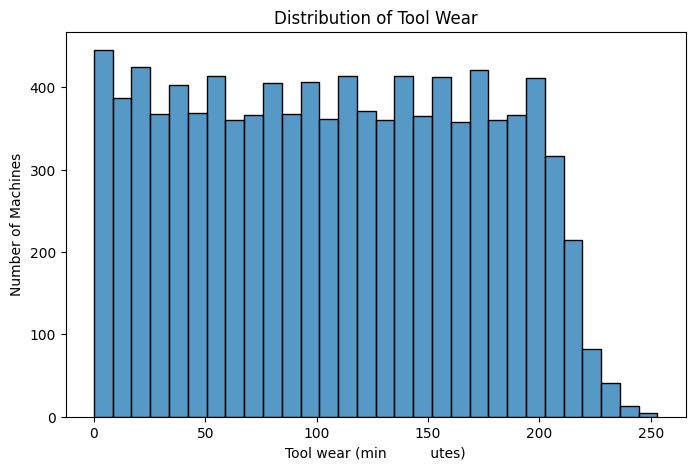

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['Tool wear [min]'], bins=30)

plt.title('Distribution of Tool Wear')
plt.xlabel('Tool wear (min          utes)')
plt.ylabel('Number of Machines')
plt.show()

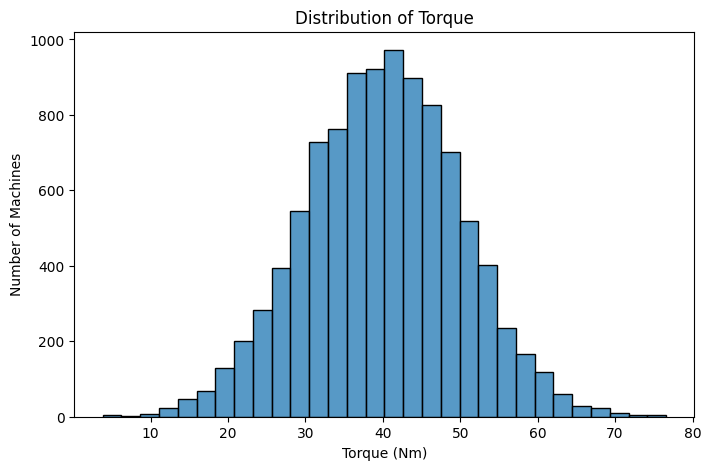

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['Torque [Nm]'], bins=30)

plt.title('Distribution of Torque')
plt.xlabel('Torque (Nm)')
plt.ylabel('Number of Machines')
plt.show()

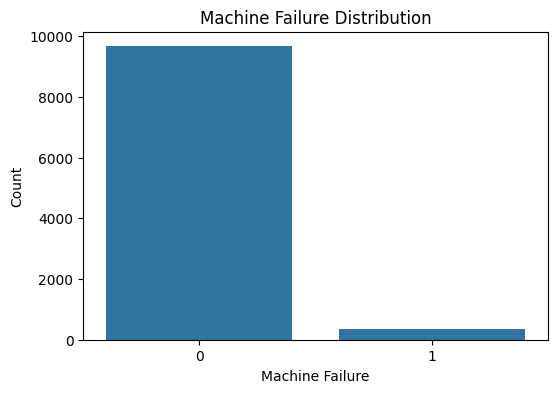

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Machine failure'
)

plt.title('Machine Failure Distribution')
plt.xlabel('Machine Failure')
plt.ylabel('Count')

plt.show()

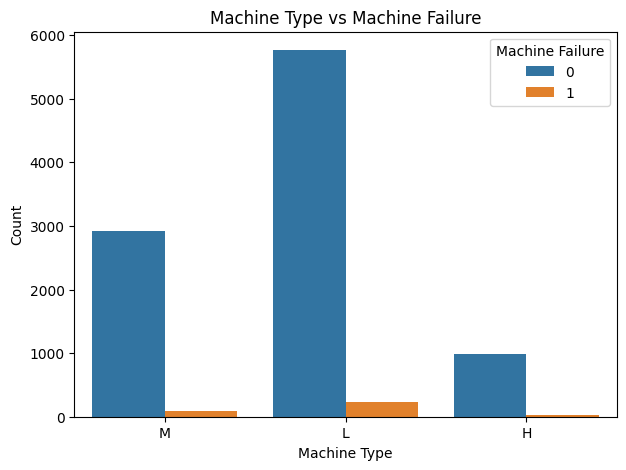

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Type',
    hue='Machine failure'
)

plt.title('Machine Type vs Machine Failure')
plt.xlabel('Machine Type')
plt.ylabel('Count')

plt.legend(title='Machine Failure')

plt.show()

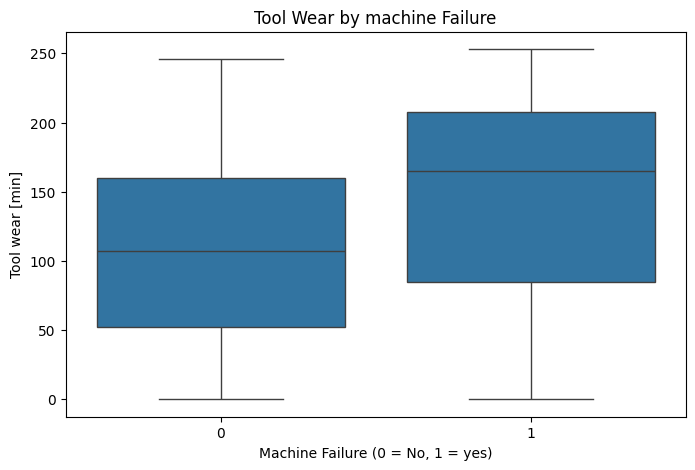

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Machine failure',
    y='Tool wear [min]'
)

plt.title('Tool Wear by machine Failure')
plt.xlabel('Machine Failure (0 = No, 1 = yes)')
plt.show()

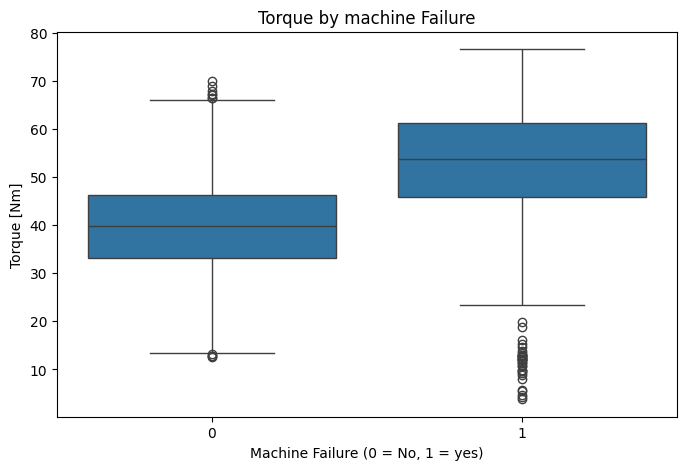

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Machine failure',
    y='Torque [Nm]'
)

plt.title('Torque by machine Failure')
plt.xlabel('Machine Failure (0 = No, 1 = yes)')
plt.show()

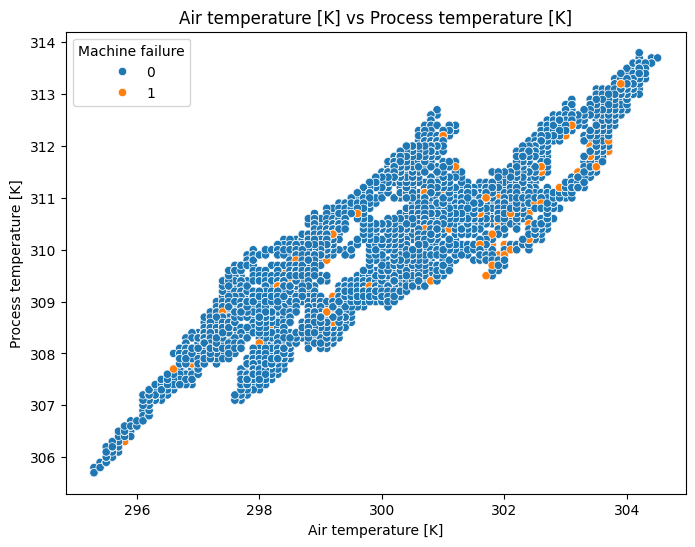

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Air temperature [K]',
    y='Process temperature [K]',
    hue='Machine failure'
)

plt.title('Air temperature [K] vs Process temperature [K]')

plt.show()

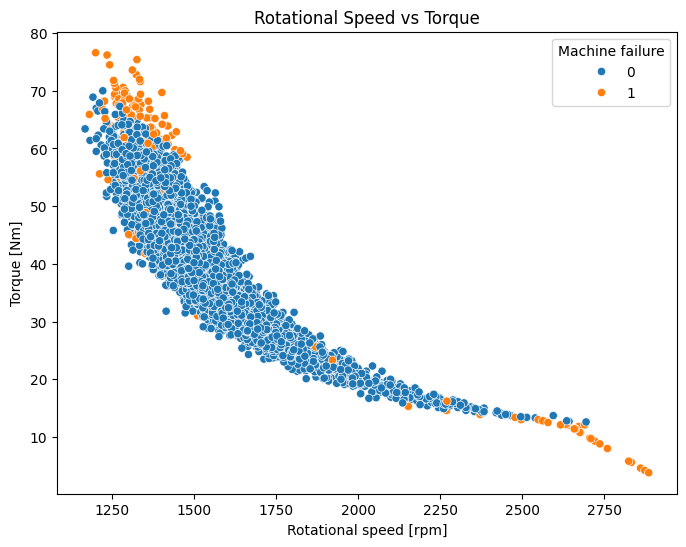

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure'
)

plt.title('Rotational Speed vs Torque')

plt.show()

In [26]:
correlation = df.corr(numeric_only=True)

correlation

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


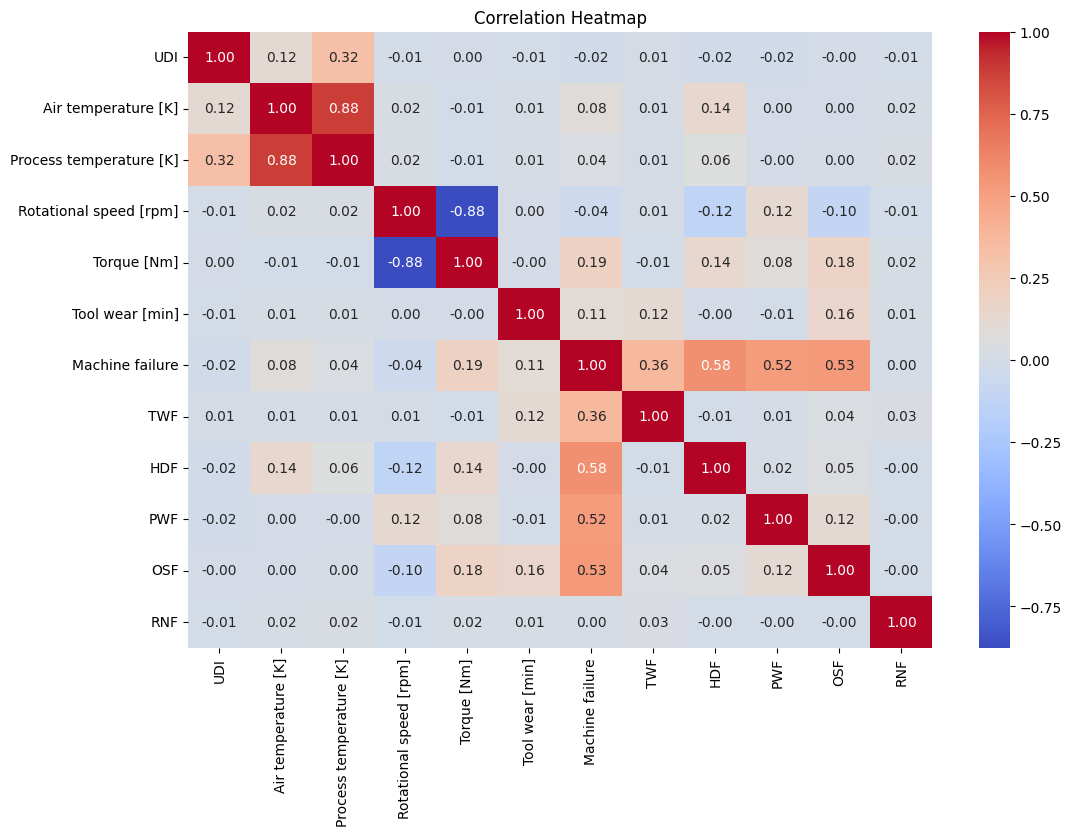

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
df_model = df.drop(
    columns=['UDI','Product ID','TWF','HDF','PWF','OSF','RNF']
)

df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [29]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


In [30]:
df_model = pd.get_dummies(
    df_model,
    columns=['Type'],
    drop_first=True
)

df_model.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [31]:
X = df_model.drop('Machine failure', axis=1)

y = df_model['Machine failure']

In [32]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [33]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 7)
(2000, 7)
(8000,)
(2000,)


In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:

Ir = LogisticRegression(random_state=42)

Ir.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [38]:
y_pred = Ir.predict(X_test_scaled)
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9675


In [40]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1928    4]
 [  61    7]]


<function matplotlib.pyplot.show(close=None, block=None)>

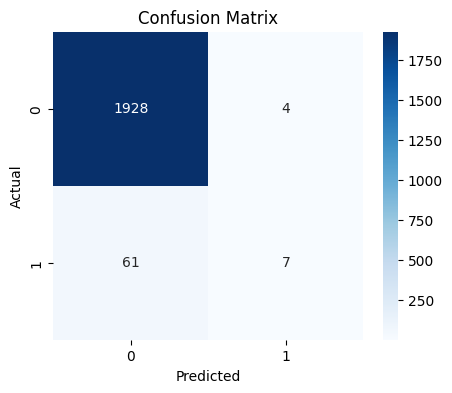

In [41]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



In [43]:
Ir_balanced = LogisticRegression(class_weight='balanced',random_state=42)

Ir_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [44]:
y_pred_balanced = Ir_balanced.predict(X_test_scaled)

In [45]:
print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

[[1593  339]
 [  12   56]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [46]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

knn_pred = knn.predict(
    X_test_scaled
)

print(classification_report(
    y_test,
    knn_pred
))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.83      0.29      0.43        68

    accuracy                           0.97      2000
   macro avg       0.90      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000



In [47]:
tree=DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
tree_pred=tree.predict(X_test)
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.68      0.66      0.67        68

    accuracy                           0.98      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [48]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Balanced Logistic",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_balanced),
        accuracy_score(y_test,knn_pred),
        accuracy_score(y_test,tree_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.9675
1,Balanced Logistic,0.8245
2,KNN,0.9740
3,Decision Tree,0.9780


In [49]:
param_grid={
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

grid=GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [50]:
best_model=grid.best_estimator_

best_pred=best_model.predict(X_test)

print(classification_report(y_test,best_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.87      0.59      0.70        68

    accuracy                           0.98      2000
   macro avg       0.93      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



<Axes: xlabel='Importance', ylabel='Feature'>

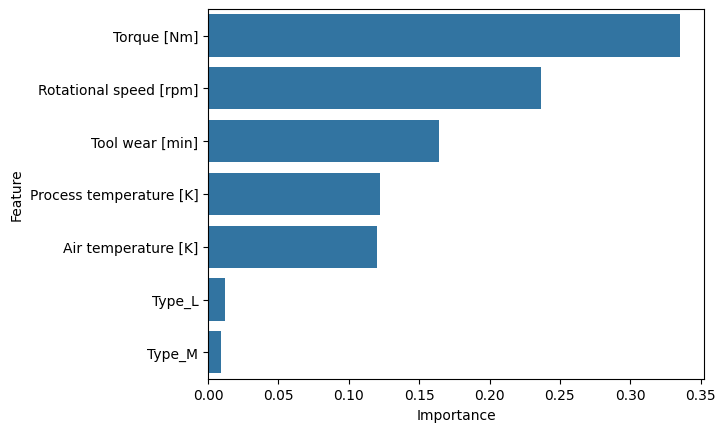

In [51]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

Text(0.5, 1.0, 'ROC Curve')

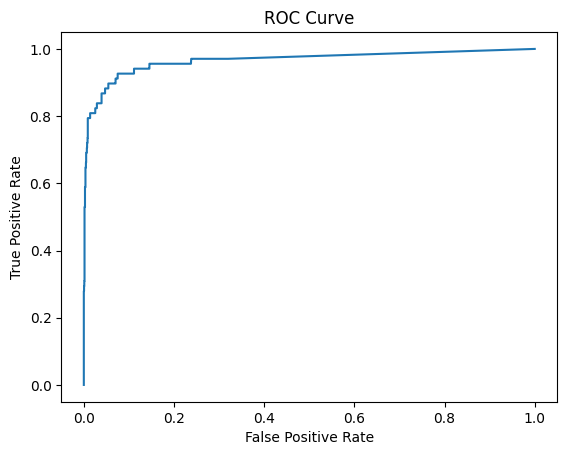

In [52]:
prob = best_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

In [53]:
joblib.dump(
    best_model,
    "predictive_maintenance.pkl"
)

['predictive_maintenance.pkl']

In [54]:
new_machine=pd.DataFrame({
    'Air temperature [K]':[300],
    'Process temperature [K]':[310],
    'Rotational speed [rpm]':[1500],
    'Torque [Nm]':[45],
    'Tool wear [min]':[150],
    'Type_L':[1],
    'Type_M':[0]
})

prediction=best_model.predict(new_machine)

print(prediction)

[0]
